In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')
import pydicom
from IPython.display import clear_output
import time
import math

from pydicom.data import get_testdata_file
from pydose_rt import ModelConfig
# from pydose_rt import ModelConfig
import numpy as np
from rt_utils import RTStructBuilder
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, rotate
from pydose_rt import DoseEngine
from pydose_rt.pydose_rt.utils.data_loading import load_rtp_data
import SimpleITK as sitk
import torch

In [2]:
# Set paths
ct_folder = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21/"
rtplan_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/FULL/RTPLAN 1.3.6.1.4.1.30071.8.31476615742634.73943573385423950215304731031.dcm"
rtdose_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21_plans/FULL/RTDOSE 1.3.6.1.4.1.30071.8.31476615742634.73943573385423938757468755518.dcm"
# Load CT

ct_image, doses, masks, mlc_inputs = load_rtp_data(ct_folder, dose_path=[rtdose_path], plan_path=[rtplan_path], scaling=400)
dose_volume = sitk.GetArrayFromImage(doses['dose_0'])
ct_volume = sitk.GetArrayFromImage(ct_image)
external_mask = sitk.GetArrayFromImage(masks["External"])
ct_volume = np.where(external_mask, ct_volume, -1000.0)

print(ct_image.GetSize())
print(dose_volume.shape)
print(ct_volume.shape)
print(sitk.GetArrayFromImage(masks["CTV"]).shape)

(266, 266, 234)
(234, 266, 266)
(234, 266, 266)
(234, 266, 266)


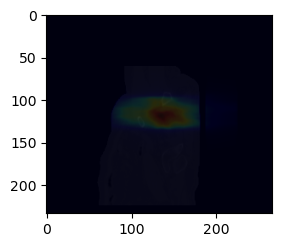

In [3]:
plt.subplot(121)
plt.imshow(ct_volume[:, :, 110], cmap='gray')
plt.imshow(dose_volume[:, :, 110], cmap='jet', alpha=0.6)
plt.imshow(sitk.GetArrayFromImage(masks["CTV"])[:, :, 110], cmap='gray', alpha=0.8)

[2.0, 2.0, 2.0]


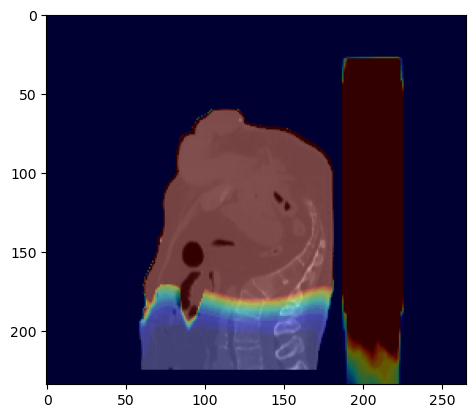

In [4]:
ct_spacing = [ct_image.GetSpacing()[0], ct_image.GetSpacing()[1], ct_image.GetSpacing()[2]]
ct_shape = ct_volume.shape

print(ct_spacing)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], alpha=0.4, cmap='jet', vmax=0.01)

In [5]:
# print(config)
# for cw_1 in [True, False]:
#     for cw_2 in [True, False]:
#         for starting_angle_1 in [0.0, 180.0]:
#             for starting_angle_2 in [0.0, 180.0]: #np.linspace(178.0, 182.0, 5, endpoint=True):
ct_slices = np.array(np.expand_dims(ct_volume, 0), dtype=np.float32)
leafs_1, mus_1 = mlc_inputs[0]
leafs_2, mus_2 = mlc_inputs[1]
results = []
config_1 = ModelConfig(preset="umea",
                    ct_array_shape=ct_shape, 
                    resolution=np.divide(ct_spacing, 10), 
                    field_size=(40, 40), 
                    downsampling_factor=(2, 2, 2), 
                    number_of_cps=178, 
                    starting_angle=180.0,
                    clockwise=True,
                    )
dose_layer_1 = DoseEngine(config_1, 55, permute_ct=False, leafs_centered=True)
jaws_1 = np.zeros(config_1.shape_jaws)
jaws_1[:, 0, :] = 0.5
jaws_1[:, 1, :] = 1.0
dose_1 = dose_layer_1(torch.tensor(np.array(leafs_1), dtype=torch.float32, device='cuda'), torch.tensor(np.array(mus_1), dtype=torch.float32, device='cuda'), torch.tensor(np.array(jaws_1), dtype=torch.float32, device='cuda'), ct_image=torch.tensor(ct_slices, dtype=torch.float32, device='cuda')).cpu().detach().numpy()

config_2 = ModelConfig(preset="umea",
                    ct_array_shape=ct_shape, 
                    resolution=np.divide(ct_spacing, 10), 
                    field_size=(40, 40), 
                    downsampling_factor=(2, 2, 2), 
                    number_of_cps=178, 
                    starting_angle=180.0,
                    clockwise=False,
                    )
dose_layer_2 = DoseEngine(config_2, 55, permute_ct=False, leafs_centered=True)
jaws_2 = jaws_1.copy()
dose_2 = dose_layer_2(torch.tensor(np.array(leafs_2), dtype=torch.float32, device='cuda'), torch.tensor(np.array(mus_2), dtype=torch.float32, device='cuda'), torch.tensor(np.array(jaws_2), dtype=torch.float32, device='cuda'), ct_image=torch.tensor(ct_slices, dtype=torch.float32, device='cuda')).cpu().detach().numpy()
dose_pred = dose_1 + dose_2
dose_pred = dose_pred * np.max(dose_volume) / np.max(dose_pred)
# dose_plot = dose_plot * (np.quantile(dose_volume, 0.999) / np.quantile(dose_plot, 0.999))
ext_mask = sitk.GetArrayFromImage(masks["External"]) > 0
diff = ext_mask * np.abs(dose_volume - dose_pred)**2
results.append(np.mean(diff))
print(np.mean(diff))
# print(f"{starting_angle_1}/{starting_angle_2}/{cw_1}/{cw_2}:\t{np.mean(diff)}") # Baseline is 0.143663

0.11414516


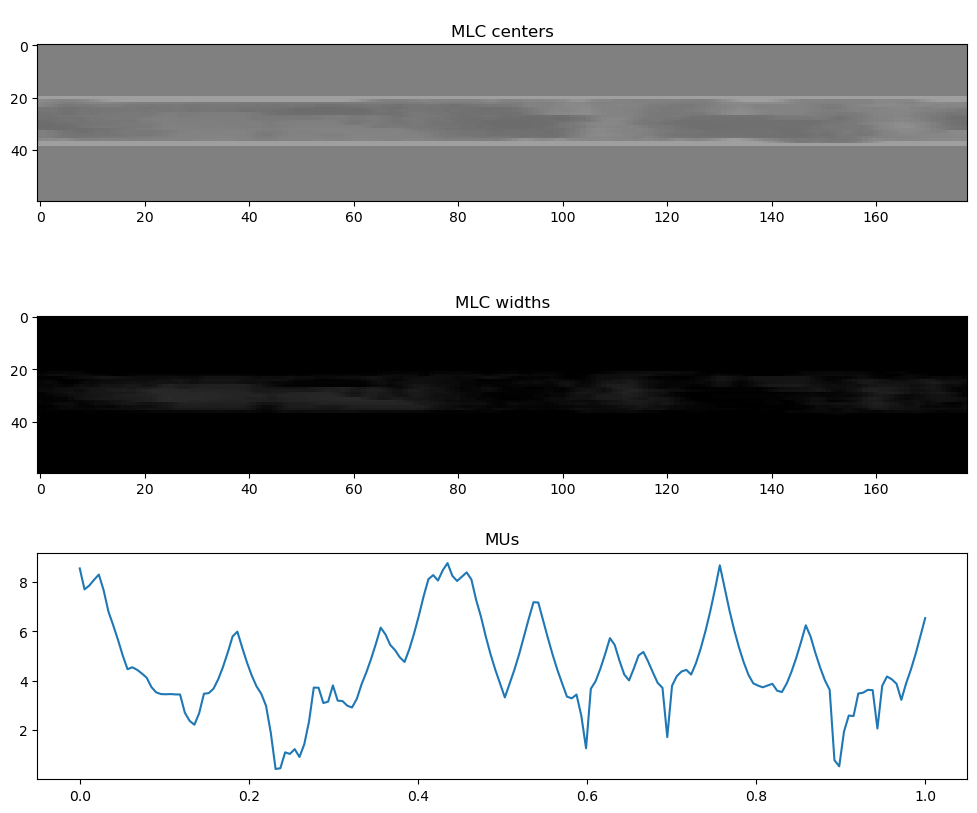

In [6]:

plt.figure(figsize=(12, 10))
plt.axis('off')
plt.subplot(311)
plt.title('MLC centers')
plt.imshow(np.transpose(torch.tensor(np.array(leafs_1), dtype=torch.float32, device='cuda').cpu().detach().numpy()[0, 0, :, :]), cmap='gray', vmin=0, vmax=1, aspect=0.5, interpolation='none')
plt.subplot(312)
plt.title('MLC widths')
plt.imshow(np.transpose(torch.tensor(np.array(leafs_1), dtype=torch.float32, device='cuda').cpu().detach().numpy()[0, 1, :, :]), cmap='gray', vmin=0, vmax=1, aspect=0.5, interpolation='none')
plt.subplot(313)
plt.title('MUs')
plt.plot(np.linspace(0, 1, 178), torch.tensor(np.array(mus_1), dtype=torch.float32, device='cuda').cpu().detach().numpy()[0, :]) #, cmap='gray', aspect=10.0, interpolation='none')
plt.show()

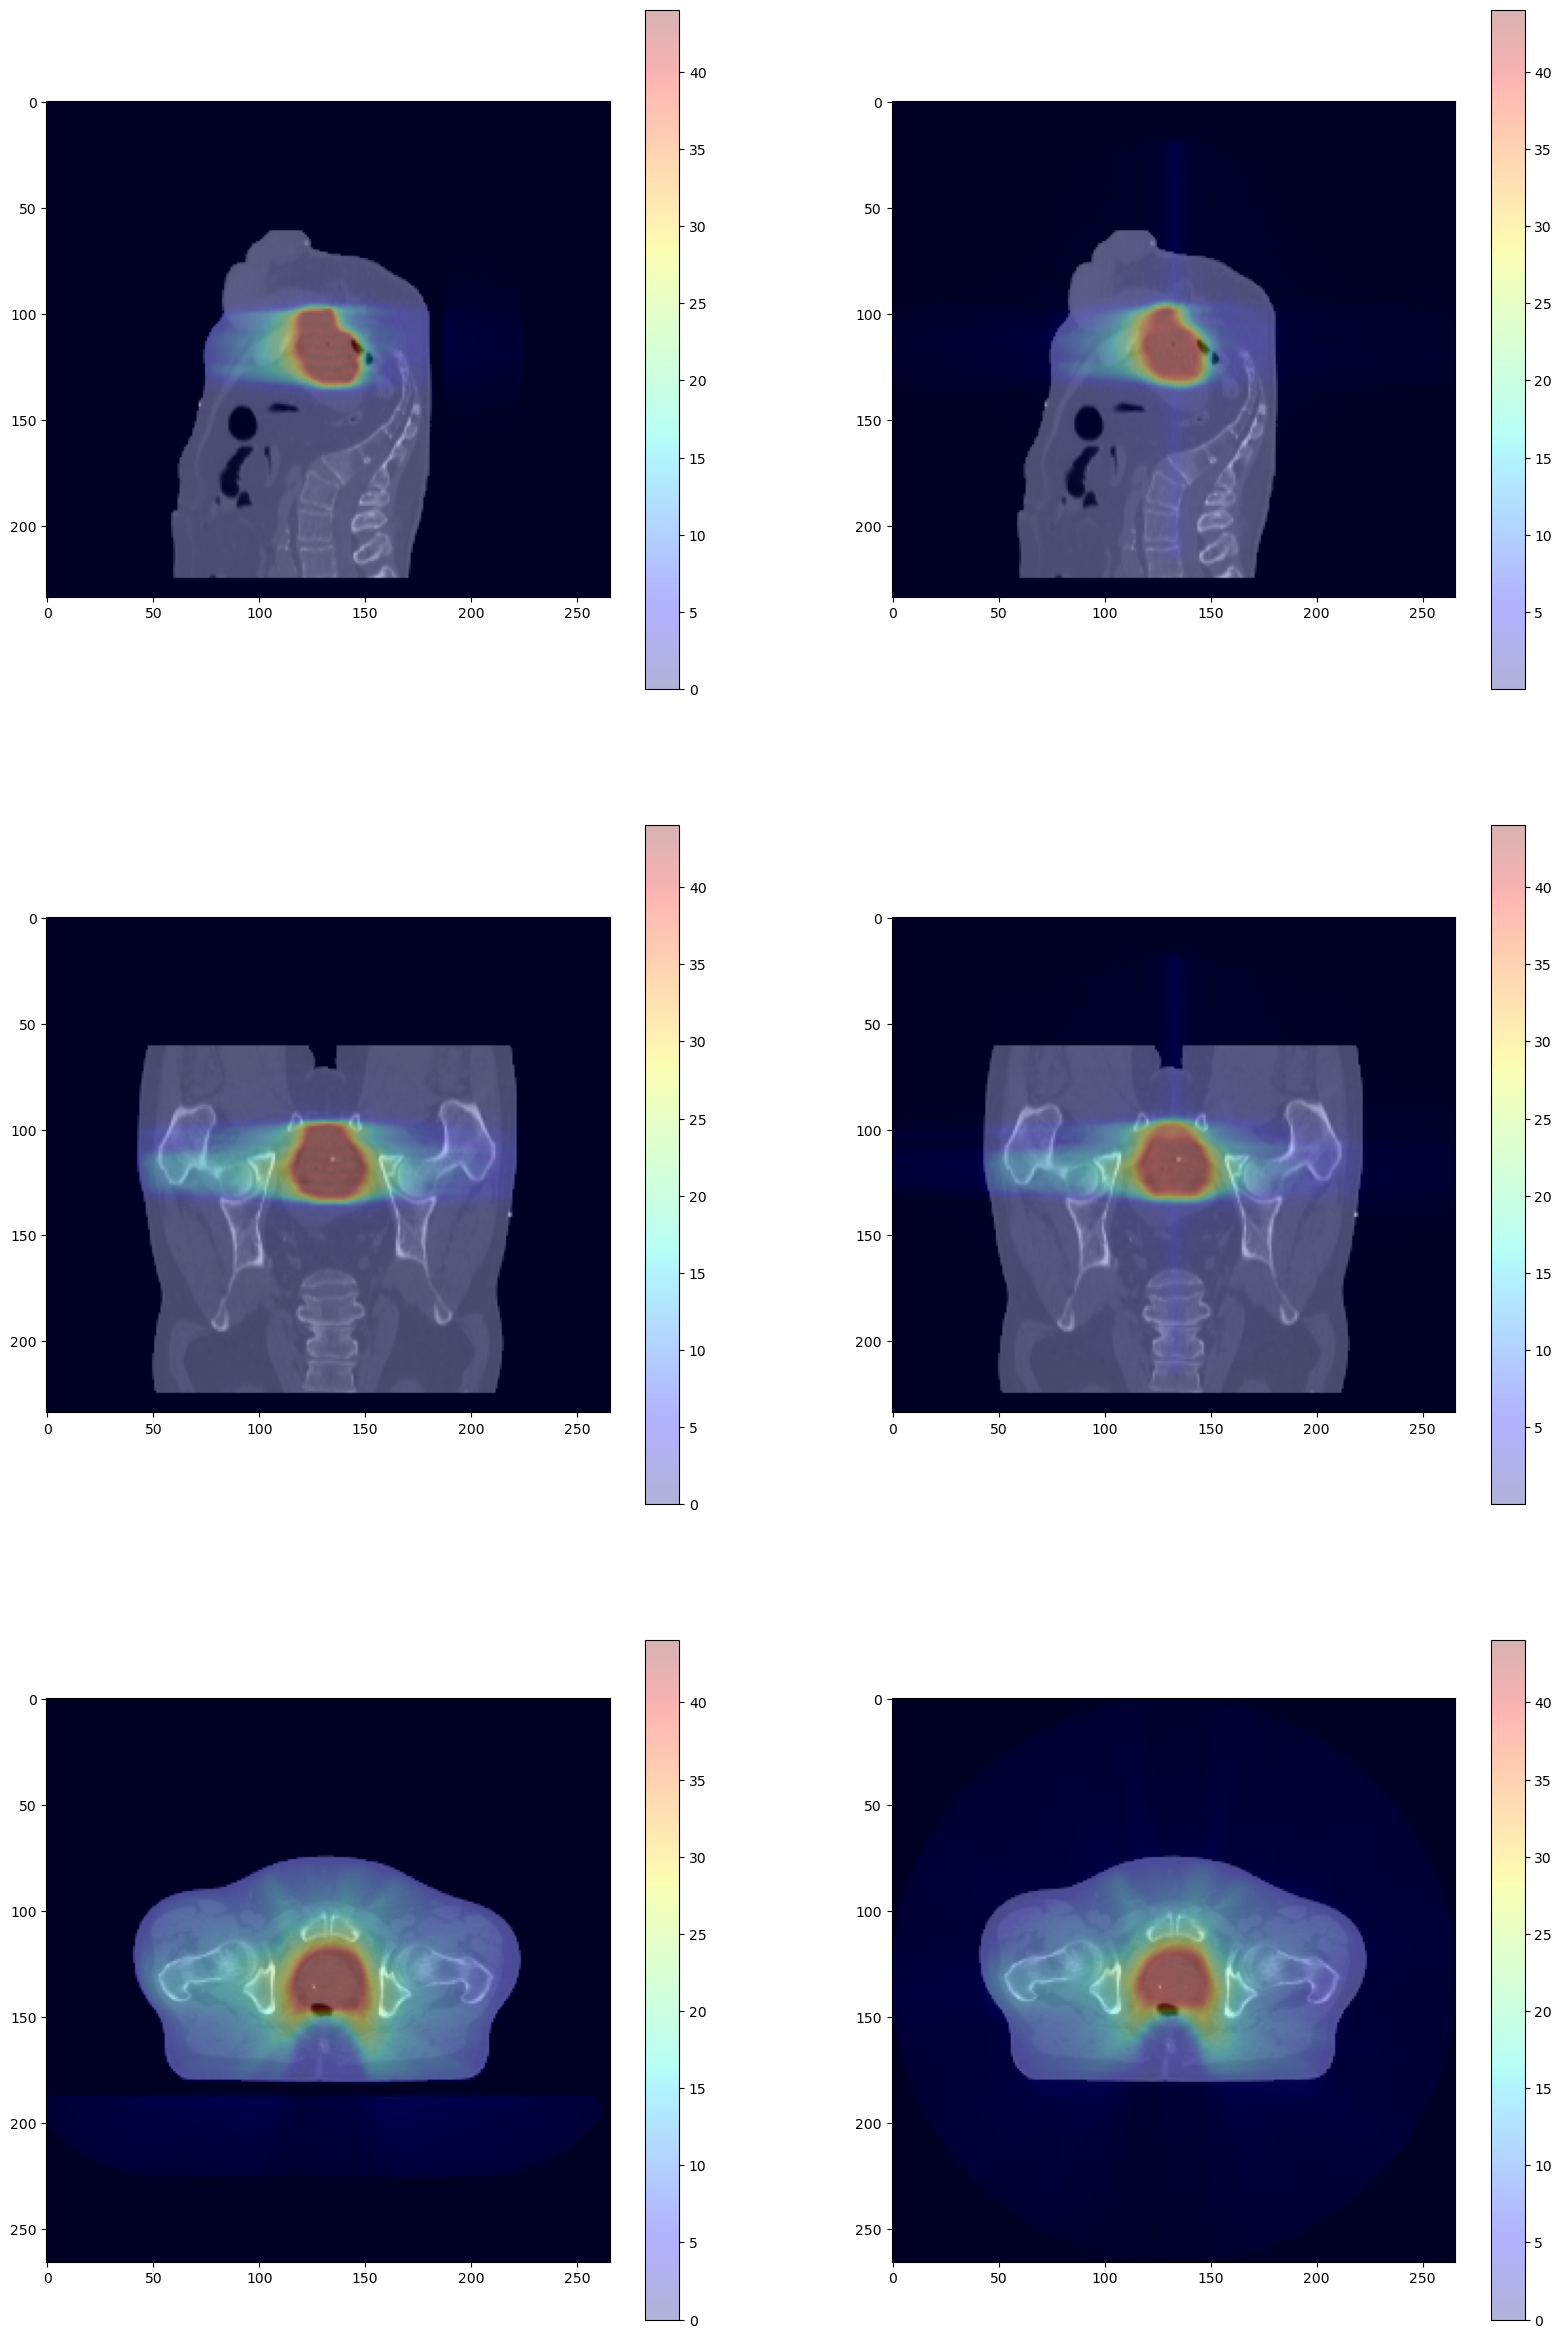

In [7]:
dose_plot = dose_pred
pred_max = np.max(dose_plot)
resampled_ct = ct_image
dose_max = np.max(dose_volume)
alpha = 0.3
plt.figure(figsize=(20, 30))
plt.subplot(321)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(322)
plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_plot[0, :, :, ct_shape[2] // 2], cmap='jet', vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(323)
plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(324)
plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_plot[0, :, ct_shape[1] // 2, :], cmap='jet', vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(325)
plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(326)
plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_plot[0, ct_shape[0] // 2, :, :], cmap='jet', vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.show()

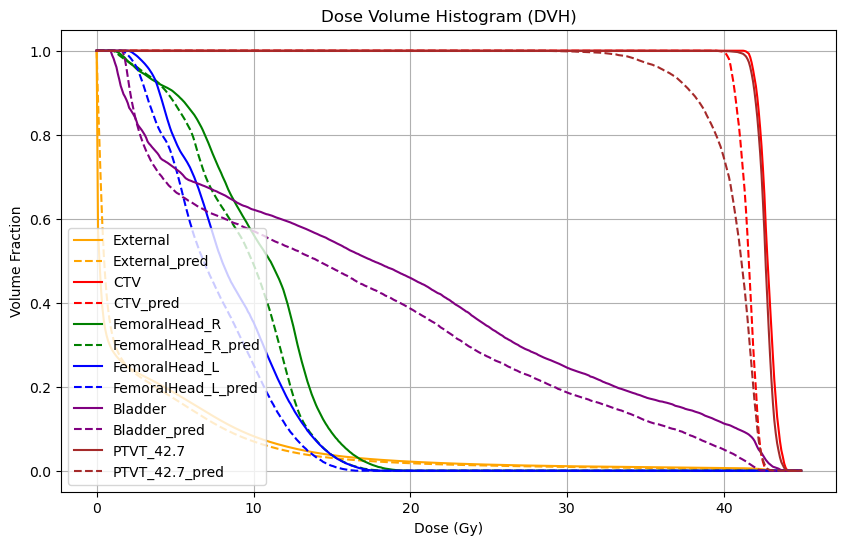

In [8]:
bins = np.linspace(0, 45.0, 500)

roi_colors = {
    "PTV": "orange",
    "ROI1": "red",
    "ROI2": "green",
    "ROI3": "blue",
    "ROI4": "purple",
    "ROI5": "brown",
    "ROI6": "black",
}

plt.figure(figsize=(10, 6))
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    dose_pred_hist = dose_pred[0][np.array(sitk.GetArrayFromImage(masks[roi_name]), dtype=np.bool_)]
    dose_gt = dose_volume[np.array(sitk.GetArrayFromImage(masks[roi_name]), dtype=np.bool_)]


    # Compute the histogram
    hist, bin_edges = np.histogram(dose_gt, bins=bins, density=False)
    cumulative_hist = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
    cumulative_hist_normalized = (
        cumulative_hist / cumulative_hist.max()
    )  # Normalize
    plt.plot(
        bin_edges[:-1],
        cumulative_hist_normalized,
        label=roi_name,
        color=color,
    )

    # Compute the histogram
    hist, bin_edges = np.histogram(dose_pred_hist, bins=bins, density=False)
    cumulative_hist = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
    cumulative_hist_normalized = (
        cumulative_hist / cumulative_hist.max()
    )  # Normalize
    plt.plot(
        bin_edges[:-1],
        cumulative_hist_normalized,
        label=roi_name+"_pred",
        linestyle='--',
        color=color,
    )

plt.xlabel("Dose (Gy)")
plt.ylabel("Volume Fraction")
plt.title("Dose Volume Histogram (DVH)")
plt.legend(loc='lower left')
plt.grid(True)

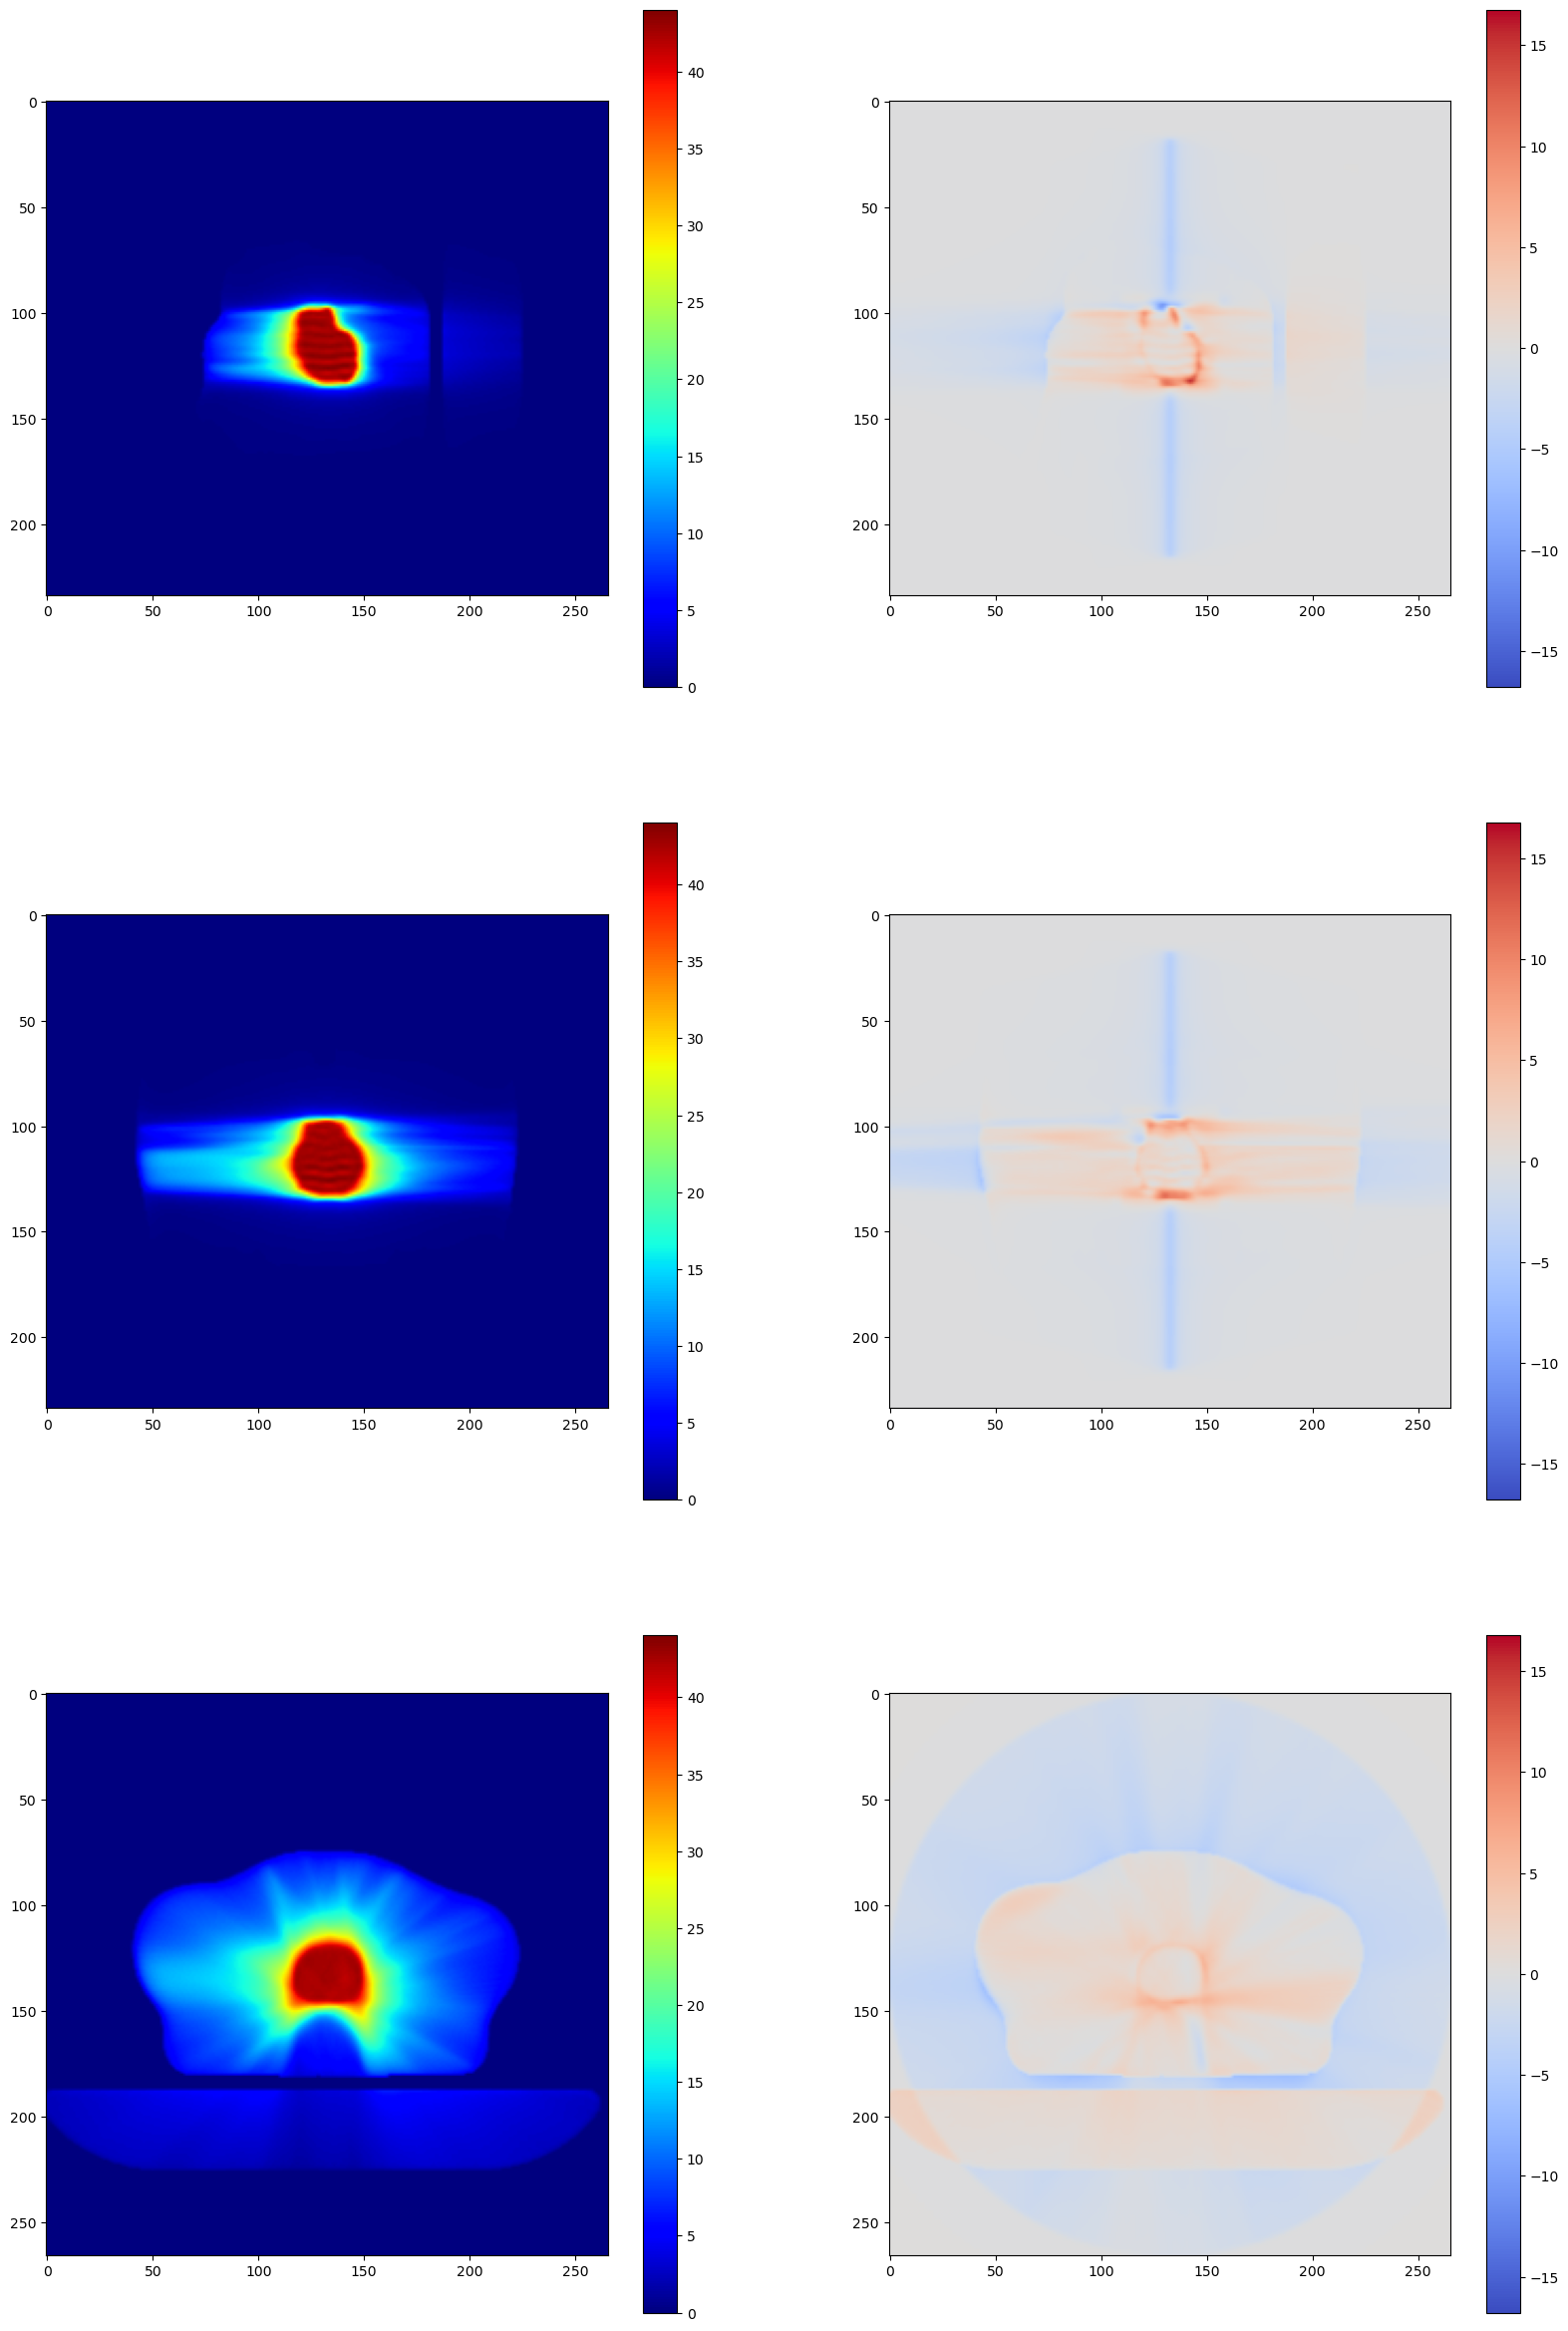

In [9]:
dose_plot = dose_pred
scale = 1.0
pred_max = scale * np.max(np.abs(dose_volume - dose_plot))
pred_min = - pred_max
resampled_ct = ct_image
dose_max = np.max(dose_volume)
alpha = 1.0
plt.figure(figsize=(20, 30))
plt.subplot(321)
# plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(322)
# plt.imshow(ct_volume[:, :, ct_shape[2] // 2], cmap='gray')
plt.imshow(dose_volume[:, :, ct_shape[2] // 2] - dose_plot[0, :, :, ct_shape[2] // 2], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(323)
# plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(324)
# plt.imshow(ct_volume[:, ct_shape[1] // 2, :], cmap='gray')
plt.imshow(dose_volume[:, ct_shape[1] // 2, :] - dose_plot[0, :, ct_shape[1] // 2, :], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.subplot(325)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :], cmap='jet', vmax=dose_max, alpha=alpha)
plt.colorbar()
plt.subplot(326)
# plt.imshow(ct_volume[ct_shape[0] // 2, :, :], cmap='gray')
plt.imshow(dose_volume[ct_shape[0] // 2, :, :] - dose_plot[0, ct_shape[0] // 2, :, :], cmap='coolwarm', vmin=pred_min, vmax=pred_max, alpha=alpha)
plt.colorbar()
plt.show()